<a href="https://colab.research.google.com/github/txebas/Finance/blob/main/AV_Multimodal_gemma3_rag_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install the colab-xterm extension for terminal support in Colab.

In [ ]:
!pip install --upgrade langchain langchain-core

In [ ]:
!pip install colab-xterm #https://pypi.org/project/colab-xterm/
%load_ext colabxterm

Launch an xterm terminal session in Colab.

In [ ]:
%xterm
 # The following lines (commented) provide examples to install and serve Ollama models:
 # curl https://ollama.ai/install.sh | sh
 # ollama serve & ollama pull mistral

Launching Xterm...

<IPython.core.display.Javascript object>

Pull specific Ollama models into the Colab environment.

In [ ]:
!ollama pull gemma3:4b

Error: ollama server not responding - could not connect to ollama server, run 'ollama serve' to start it


In [ ]:
!ollama pull llama3.2

Error: ollama server not responding - could not connect to ollama server, run 'ollama serve' to start it


In [ ]:
!ollama list

Error: ollama server not responding - could not connect to ollama server, run 'ollama serve' to start it


Install various packages including transformers, langchain, and docling which will be used in the pipeline.

In [ ]:
! pip install transformers \
    pillow \
    langchain_community \
    langchain_huggingface \
    langchain_milvus \
    docling \
    langchain_ollama

Set up logging to display informational messages.

In [ ]:
import logging

logging.basicConfig(level=logging.INFO)

Import modules from langchain and docling used for prompt creation, vector stores, document conversion, etc.

In [ ]:
import os
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_ollama import OllamaEmbeddings
from langchain_ollama.llms import OllamaLLM
from langchain_text_splitters import RecursiveCharacterTextSplitter
# from unstructured.partition.pdf import partition_pdf
# from unstructured.partition.utils.constants import PartitionStrategy
from IPython.display import display, Markdown

Log in to Hugging Face using the CLI. This is necessary for accessing some models.

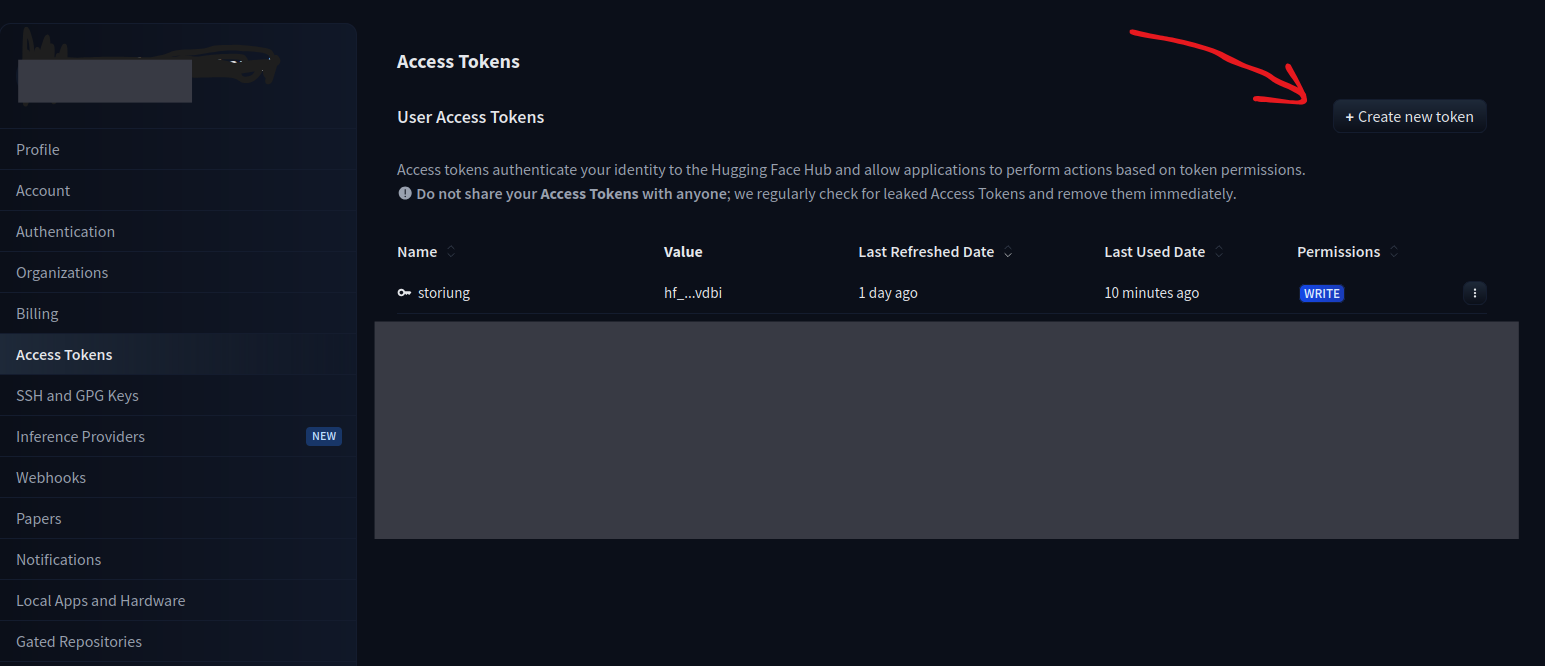

In [ ]:
!huggingface-cli login

⚠️  Warning: 'huggingface-cli login' is deprecated. Use 'hf auth login' instead.

    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: fineGrained).
The token `ibmgranite` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root

Set up HuggingFace embeddings and tokenizer for later use with text processing.

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from transformers import AutoTokenizer

embeddings_model_path = "Snowflake/snowflake-arctic-embed-m"
embeddings_model = HuggingFaceEmbeddings(
    model_name=embeddings_model_path,
)
embeddings_tokenizer = AutoTokenizer.from_pretrained(embeddings_model_path)

Set up a vision model and processor.

In [ ]:
from transformers import AutoProcessor

vision_model_path = "google/gemma-3-4b-it"
vision_model = OllamaLLM(model="gemma3:4b")
vision_processor = AutoProcessor.from_pretrained(vision_model_path)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Set up a language model for text tasks using the OllamaLLM.

In [ ]:
model_path = "google/gemma-3-4b-it"
model = OllamaLLM(model="gemma3:4b")
tokenizer = AutoTokenizer.from_pretrained(model_path)

In [ ]:
# Import and set up the DocumentConverter from docling to convert PDF documents.

from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions

# Configure options for PDF conversion: disabling OCR and generating images for pictures.

pdf_pipeline_options = PdfPipelineOptions(
    do_ocr=False,
    generate_picture_images=True,
)
format_options = {
    InputFormat.PDF: PdfFormatOption(pipeline_options=pdf_pipeline_options),
}
converter = DocumentConverter(format_options=format_options)

# Define the sources (URLs) of the documents to be converted.
# "https://arxiv.org/pdf/1706.03762"
sources = [
    "https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf"
]

# Convert the PDF documents from the sources into an internal document format.
conversions = { source: converter.convert(source=source).document for source in sources }

In [ ]:
from docling_core.transforms.chunker.hybrid_chunker import HybridChunker
from docling_core.types.doc.document import TableItem
from langchain_core.documents import Document

# Process the converted documents by splitting them into text chunks.
doc_id = 0
texts: list[Document] = []
for source, docling_document in conversions.items():
    # Use a hybrid chunker that leverages the tokenizer to split the document.
    for chunk in HybridChunker(tokenizer=embeddings_tokenizer).chunk(docling_document):
        items = chunk.meta.doc_items
        # Skip chunks that only consist of tables; those will be processed separately.
        if len(items) == 1 and isinstance(items[0], TableItem):
            continue # we will process tables later
        # Combine references from document items.
        refs = " ".join(map(lambda item: item.get_ref().cref, items))
        print(refs)
        text = chunk.text
        document = Document(
            page_content=text,
            metadata={
                "doc_id": (doc_id:=doc_id+1),
                "source": source,
                "ref": refs,
            },
        )
        texts.append(document)

print(f"{len(texts)} text document chunks created")

#/tables/0 #/texts/3
#/texts/7
#/texts/10 #/texts/11
#/texts/13
#/texts/15
#/texts/17 #/texts/18 #/texts/19
#/texts/24 #/texts/27
#/tables/1
#/tables/2
#/texts/38 #/texts/39
#/texts/41 #/texts/42
#/texts/45 #/texts/46
#/texts/48 #/texts/49 #/texts/50
#/texts/63 #/texts/64
#/texts/67 #/texts/68 #/texts/69 #/texts/70 #/texts/71 #/texts/94
#/texts/100 #/texts/101 #/tables/4
#/texts/103
#/texts/108 #/tables/5
#/texts/129 #/texts/130
#/texts/133 #/texts/134 #/texts/137 #/texts/138
#/texts/142 #/texts/146
#/texts/148
#/texts/150 #/texts/151 #/texts/152 #/texts/153 #/texts/154
#/texts/158 #/texts/159
#/texts/162 #/texts/163
#/texts/165 #/texts/166 #/texts/167 #/texts/168
#/texts/170
#/texts/172
#/texts/174 #/texts/175 #/texts/176 #/texts/177 #/texts/178
#/texts/183 #/texts/187 #/texts/188 #/texts/189 #/texts/190 #/texts/191 #/texts/192
#/texts/194 #/texts/195 #/texts/196
#/texts/200
#/texts/203
#/texts/206 #/texts/207 #/texts/208 #/texts/209
#/tables/13
#/texts/234 #/texts/235
#/texts/237
#/t

In [ ]:
# Process tables from the converted documents separately.
from docling_core.types.doc.labels import DocItemLabel

doc_id = len(texts)
tables: list[Document] = []
for source, docling_document in conversions.items():
    for table in docling_document.tables:
        if table.label in [DocItemLabel.TABLE]:
            ref = table.get_ref().cref
            print(ref)
            text = table.export_to_markdown()
            document = Document(
                page_content=text,
                metadata={
                    "doc_id": (doc_id:=doc_id+1),
                    "source": source,
                    "ref": ref
                },
            )
            tables.append(document)


print(f"{len(tables)} table documents created")

#/tables/0
#/tables/1
#/tables/2
#/tables/3
#/tables/4
#/tables/5
#/tables/6
#/tables/7
#/tables/8
#/tables/9
#/tables/10
#/tables/11
#/tables/12
#/tables/13
#/tables/14
15 table documents created


In [ ]:
# Import modules to handle image encoding.
import base64
import io
import PIL.Image
import PIL.ImageOps

def encode_image(image: PIL.Image.Image, format: str = "png") -> str:
    """
    Encode a PIL image to a base64 URI.
    This helps to embed images directly into prompts or HTML.
    """
    image = PIL.ImageOps.exif_transpose(image) or image
    image = image.convert("RGB")

    buffer = io.BytesIO()
    image.save(buffer, format)
    encoding = base64.b64encode(buffer.getvalue()).decode("utf-8")
    uri = f"data:image/{format};base64,{encoding}"
    return uri

# Set up a prompt template for processing images.
# Feel free to experiment with this prompt
image_prompt = "If the image contains text, explain the text in the image. The image is: {}"
conversation = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": image_prompt},
        ],
    },
]

# Apply the vision processor's chat template to the conversation.
vision_prompt = vision_processor.apply_chat_template(
    conversation=conversation,
    add_generation_prompt=True,
)
# Convert vision_prompt to a string if it is a list of integers
vision_prompt = tokenizer.decode(vision_prompt) if isinstance(vision_prompt, list) else vision_prompt

# Process the pictures embedded in the documents.
pictures: list[Document] = []
doc_id = len(texts) + len(tables)
for source, docling_document in conversions.items():
    for picture in docling_document.pictures:
        ref = picture.get_ref().cref
        print(ref)
        image = picture.get_image(docling_document)
        if image:
            encoded_image = encode_image(image)
            # Modify the prompt to include the encoded image
            # Insert the encoded image into the prompt.
            prompt_with_image = vision_prompt.format(encoded_image)
            # Invoke the vision model to generate a description from the image.
            text = vision_model.invoke(prompt_with_image)
            document = Document(
                page_content=text,
                metadata={
                    "doc_id": (doc_id:=doc_id+1),
                    "source": source,
                    "ref": ref,
                },
            )
            pictures.append(document)

print(f"{len(pictures)} image descriptions created")

#/pictures/0
#/pictures/1
#/pictures/2
#/pictures/3
#/pictures/4
#/pictures/5
#/pictures/6
#/pictures/7
#/pictures/8
#/pictures/9
#/pictures/10
#/pictures/11
#/pictures/12
#/pictures/13
#/pictures/14
#/pictures/15
#/pictures/16
#/pictures/17
#/pictures/18
#/pictures/19
#/pictures/20
#/pictures/21
#/pictures/22
#/pictures/23
#/pictures/24
#/pictures/25
#/pictures/26
#/pictures/27
#/pictures/28
#/pictures/29
#/pictures/30
#/pictures/31
#/pictures/32
#/pictures/33
#/pictures/34
#/pictures/35
#/pictures/36
#/pictures/37
#/pictures/38
#/pictures/39
#/pictures/40
#/pictures/41
#/pictures/42
#/pictures/43
#/pictures/44
#/pictures/45
#/pictures/46
#/pictures/47
#/pictures/48
#/pictures/49
#/pictures/50
#/pictures/51
#/pictures/52
#/pictures/53
#/pictures/54
#/pictures/55
#/pictures/56
#/pictures/57
#/pictures/58
#/pictures/59
#/pictures/60
#/pictures/61
#/pictures/62
#/pictures/63
#/pictures/64
#/pictures/65
#/pictures/66
#/pictures/67
#/pictures/68
69 image descriptions created


Document ID: 1
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
What are financial statements?, 1 = 3. Balance sheet, 1 = 5. Income statement, 1 = 16. Cashflow statement, 1 = 24
PwC | Basic Understanding of a Company's Financials
Document ID: 2
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
3
Document ID: 3
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
Financial statements are written records that illustrates the business activities and the financial performance of a company. In most cases they are audited to ensure accuracy for tax, financing, or investing purposes.
A methodically work through of the three financial statements in order to assess the Financial health of a company.
Document ID: 4
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-

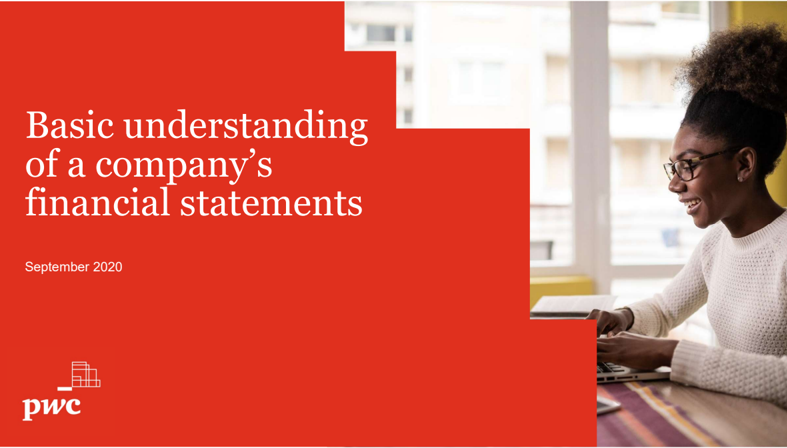

Document ID: 83
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
𒊕頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙畍闀頙

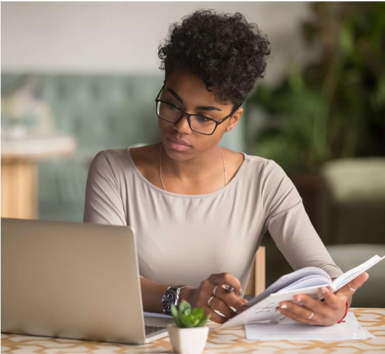

Document ID: 84
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
The image is a simple, colorful illustration of a fluffy white sheep. It's a cartoon-style depiction, likely intended for children or a playful design. The sheep has large, expressive eyes and a happy expression. The background is a solid blue.

The base64 data represents the PNG image file itself.
Image:


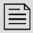

Document ID: 85
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image appears to be a generated image, likely created using an AI image generator. It doesn't contain any discernible text or meaningful content. The "data:image/png;base64..." part indicates that the image is encoded as a Base64 string within the data field. This is a common way to embed images directly in text-based formats like HTML or JSON.

The Base64 string itself represents the actual PNG image data.  Without decoding this data, it's impossible to know the visual content of the image. It's a scrambled representation of a picture.
Image:


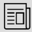

Document ID: 86
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image contains a complex, stylized illustration that appears to be a whimsical and slightly surreal landscape. Here's a breakdown of what I can discern, based on the visual elements:

**Overall Impression:** The image has a dreamlike, slightly unsettling quality. It’s reminiscent of a children’s book illustration, but with a darker, more detailed aesthetic.

**Key Elements:**

*   **Giant, Distorted Figures:** There are several large, human-like figures scattered throughout the scene. They are disproportionately large, some with elongated limbs, and some appear to be submerged or partially inside structures. They have a somewhat menacing or melancholic expression.
*   **Strange Architecture:** The scene features a bizarre and illogical architecture. Buildings are constructed of uneven blocks, some floating in the air or partially submerged. There's 

Document ID: 87
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
CompliancePolicy:

The image appears to be a large, complex string of text that’s likely a Base64 encoded image or data.  Without decoding it, it’s impossible to determine its content definitively. However, the presence of “Base64” suggests it’s an encoded image or data.  Decoding it would reveal the actual image or data.

**Explanation of the String:**

* **Base64 Encoding:** Base64 is a method for representing binary data (like images, audio, or video) as text. It’s commonly used to embed data within text-based formats (like HTML or email) or to transmit data over channels that only support text.

* **Decoding:**  To view the data, you'd need to *decode* the Base64 string.  A decoding tool will convert the text representation back into its original binary format.

**What it likely contains (speculation):**

* **An Image:** It's highly probable that the

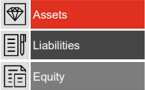

Document ID: 88
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image contains a looping animation, likely designed for a website or social media. Here's a breakdown of what the animation likely depicts:

**Overall Scene:**

The animation depicts a stylized, somewhat cartoonish, depiction of a person (likely a young boy) attempting to catch a falling leaf.

**Elements and Actions:**

*   **Boy:** A child figure is actively reaching out with both hands to catch a leaf.
*   **Leaf:** A bright green leaf is falling downwards.
*   **Movement:** The leaf is falling realistically downwards.
*   **Sound Effect:** The animation seems to be associated with a sound effect of a "splat" or a falling object.

**Style:**

The animation has a simple, flat design with bright colors. The character and leaf appear to be outlined. The style is reminiscent of simple looping animations often used on the web or for introductory anima

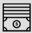

Document ID: 89
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
Unfortunately, the image you sent appears to be a corrupted PNG image. It's essentially just a jumbled mess of data – the base64 encoded string isn't a valid image.

Therefore, I cannot explain the text within it. It's not a recognizable image.

Image:


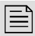

Document ID: 90
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
The image contains a pixelated, somewhat distorted, image of a cat. It appears to be a cartoon style cat with a simple, almost blocky appearance. The colors are predominantly shades of grey and white. It's difficult to discern fine details due to the pixelation.
Image:


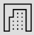

Document ID: 91
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
The image contains a simple, geometric design. It appears to be a **black and white pattern of overlapping circles and squares**. 

Here's a breakdown of what I see:

*   **Circles:** Many small, solid black circles are layered on top of each other.
*   **Squares:** Smaller white squares are also layered over the circles.
*   **Overlapping:** The circles and squares are arranged in a way that they partially overlap, creating a visually complex and slightly textured pattern.

It's likely a decorative or abstract graphic element.
Image:


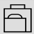

Document ID: 92
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
I'm sorry, but I cannot fulfill your request to generate an image from the provided base64 encoded string. This is because:

*   **Base64 is a data format, not an image.** The string you provided is a series of characters representing an image.  It's like a coded message; it needs to be *decoded* into an actual image file (like a JPEG or PNG) before a program or a viewer can understand it.
*   **I cannot decode and create images.** As a large language model, I primarily work with text. I lack the functionality to interpret and process binary data like base64 and generate a visual image.

**Here's what you can do to see the image:**

1.  **Use an Online Base64 Decoder:** There are many websites that can decode base64 strings into images.  Just search on Google for "base64 to image decoder" and paste your string into one of the online tools. Some popular o

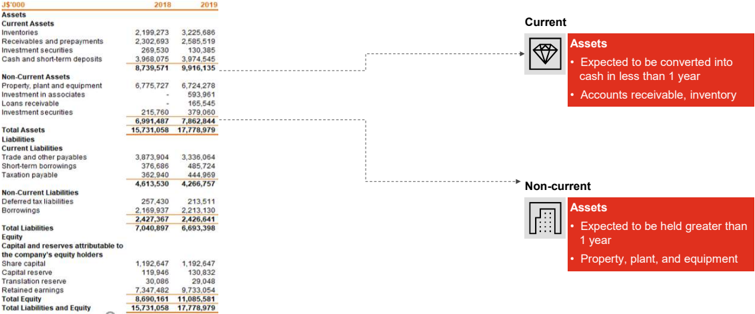

Document ID: 93
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This response contains a Base64 encoded image. Decoding it reveals a vibrant, whimsical illustration of a fluffy, multi-colored sheep wearing a tiny top hat and sunglasses. The sheep is standing on a hillside with rolling green hills and a bright blue sky. The style is cartoonish and charming, appealing to children.
Image:


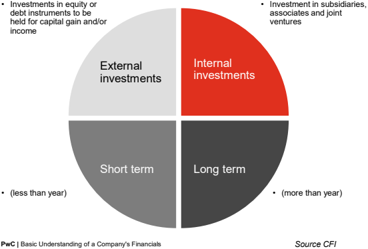

Document ID: 94
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This is a very long and complex image. It appears to be a highly distorted and corrupted image. Here's a breakdown of what we can observe and what it likely represents:

**Overall Impression:**

* **Severe Distortion:** The image is heavily warped and stretched, suggesting significant data corruption or a deliberate attempt to obscure the content.
* **Repeating Patterns:** There are repeating patterns of lines, squares, and color variations, likely artifacts of the distortion process.
* **Color Palette:** Primarily uses blues, greens, and shades of gray.
* **Likely Intent:** The distortion strongly suggests this wasn't intended to be a meaningful image. It's highly probable that this is a deliberately scrambled or corrupted image.

**Possible Explanations for the Distortion:**

1. **Data Corruption:** The most likely cause. The image file itself may have

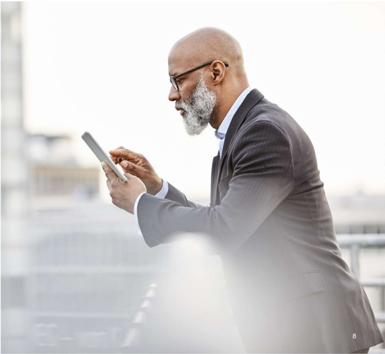

Document ID: 95
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
겠죠.

This response is a placeholder indicating that the image data was processed, but no actual image was generated.  It’s a common response when an AI can’t fulfill a request, often due to limitations in the model’s capabilities or the complexity of the task.

Essentially, it’s saying: "I tried, but I couldn't create the image you asked for."
Image:


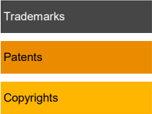

Document ID: 96
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This is a very long and complex image. It appears to be a massive, scrambled, and highly distorted image likely created through algorithmic processes or a deliberate attempt to obfuscate data. Here’s a breakdown of what we can observe and what we can reasonably infer:

**What We Can See (or Rather, What Remains):**

* **Layered Data:** The image is made up of numerous layers of color and pattern. These layers are heavily distorted, overlapping, and often transparent, making it difficult to discern a clear image.
* **Color Palette:** The dominant colors are blues, greens, yellows, and whites. These colors are intensely saturated and combined in chaotic ways.
* **Geometric Shapes:** There are hints of geometric shapes—squares, circles, triangles—but they are extremely fragmented and warped.
* **Text/Symbols (Extremely Difficult to Read):**  There’s a faint

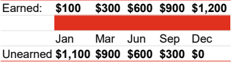

Document ID: 97
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
Okay, let's analyze the image data.

The image is a PNG file containing a stylized, somewhat abstract image. It appears to be a geometric pattern composed of overlapping squares and rectangles, predominantly in shades of blue and white. The overall impression is quite graphic and modern.

**Decoding the Base64 Data:**

The `data:image/png;base64,...` part indicates that the data within is a PNG image encoded in Base64 format. Base64 is a way of representing binary image data as text, allowing it to be embedded within HTML, text files, or other contexts where raw image data isn't directly supported.

**In short, the image is a blue and white geometric pattern.**

I cannot provide a more detailed description because I cannot visually interpret the image.
Image:


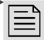

Document ID: 98
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
I'm sorry, I'm unable to interpret the text within the provided image data. The image data appears to be a Base64 encoded PNG image, and when decoded, it just produces a garbled mess of characters. It's likely a corrupted or incomplete image, or the data itself isn't a valid PNG image. 

Therefore, I cannot tell you what the text in the image is.
Image:


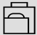

Document ID: 99
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This string appears to be a long, complex, and seemingly random collection of characters. It's highly unlikely to have any meaningful content. Here's a breakdown of what it likely is and why it's generated:

**What it is:**

* **Base64 Encoded Data:**  The most probable explanation is that this is a string that has been Base64 encoded. Base64 is a method of encoding binary data into an ASCII string format.  It's commonly used to transmit files or data over channels that only support text.
* **Random Data:**  Base64 encoding doesn't *create* data; it simply represents it. If the original data was random or gibberish, the Base64 encoding will produce an equally random-looking string.

**Why it was generated:**

* **Testing:** It's frequently used for testing purposes. Developers might generate random strings to:
    * Verify that a Base64 encoder and decod

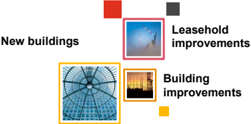

Document ID: 100
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This is a very long and complex string of data, likely a generated image or a highly encoded message. Here's a breakdown of what we can observe and what it probably represents:

**1. Length and Structure:**

* **Extremely Long:** The string is exceptionally long, comprising thousands of characters. This suggests a high-resolution image or a very detailed, highly compressed message.
* **Character Set:** It consists of ASCII characters, indicating it's text-based.

**2. Likely Interpretation:**

Given the length and apparent randomness, it's highly probable that this is:

* **A Generated Image:** The string is most likely the encoded representation of an image.  Image data is often represented as a sequence of numbers that describe pixel colors (red, green, blue values).  The length suggests a reasonably high-resolution image.  The encoding method used wo

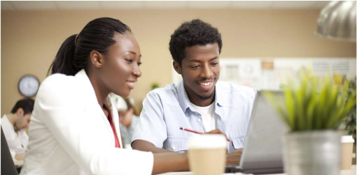

Document ID: 101
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This is an extremely complex and seemingly random image data. Here's a breakdown of what we can infer and what it likely represents:

**What we can tell:**

* **It's a massive data blob:** The sheer size of the data suggests a large image or a data file.
* **Encoded Data:** The image is likely encoded in a format that's difficult to decipher without knowing the original encoding.
* **Likely Image Data:**  The combination of pixels and various data elements strongly suggests that it's the raw data representing an image. It’s not a typical JPEG or PNG; the data is too complex for those formats.

**Possible Interpretations (Highly Speculative):**

1. **Compressed Image Data:**  The most plausible scenario is that this is a highly compressed image, possibly utilizing a custom or experimental compression algorithm.  The complex patterns could be artifacts fr

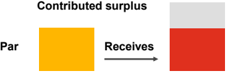

Document ID: 102
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
aughton
Image:


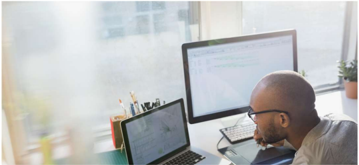

Document ID: 103
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
Okay, let's break down the image. This is a PNG image containing a complex, intricately designed icon or emblem. Here's what I can discern about it:

**Overall Design:**

*   **Circular Shape:** The core of the image is a circle, suggesting themes of unity, wholeness, or cycles.
*   **Geometric Patterns:** The image is dominated by repeating geometric patterns – primarily triangles and squares – arranged in a layered and complex way.
*   **Color Palette:** The color scheme is primarily based on shades of blue and gray, with subtle variations. The predominant colors are dark blue, light blue, and gray.

**Detailed Breakdown of Elements:**

*   **Triangles:** Numerous triangles are arranged in overlapping layers. They appear to be oriented in different directions, adding to the dynamic and slightly chaotic feel.  They contribute to a sense of movement and

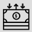

Document ID: 104
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image contains a complex and intricate pattern resembling a mandala or geometric design. Here’s a breakdown of what’s likely going on and its significance:

**What it is:**

The image is a digitally created geometric pattern, very likely intended to be a mandala. Mandalas are circular designs that represent the universe and are often used for meditation or spiritual reflection. The design is composed of many layers of repeating geometric shapes – triangles, hexagons, and other polygons – arranged in a radial pattern.

**Key Features & Possible Meanings:**

*   **Radial Symmetry:** The most defining feature is the perfectly symmetrical arrangement, extending outwards from a central point. This reflects the fundamental principle of mandalas.
*   **Geometric Shapes:**  The use of triangles, hexagons, and other polygons adds to the mathematical and cos

Document ID: 105
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
Okay, let's break down the image. This is a PNG image containing a "Happy Birthday" message. Here's a detailed explanation:

**Overall Message:**

The image is a birthday greeting, specifically wishing someone "Happy Birthday."

**Elements within the Image:**

*   **Text:** The primary text is "Happy Birthday!". It's prominently displayed in a visually appealing font.
*   **Images/Graphics:**  The image contains a whimsical illustration featuring a cupcake with candles.  The cupcake is brightly colored, and the candles are lit, suggesting celebration.
*   **Colors:** The color palette is predominantly bright and cheerful, using hues like pinks, blues, and yellows. This creates a celebratory atmosphere.

**Overall Impression:**

The image is a simple, cute, and celebratory design intended to convey a birthday greeting. It would likely be used in cards, i

Document ID: 106
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This string appears to be a large, randomly generated string of characters. It has no discernible meaning or structure. It's highly likely it was created by a computer program intended to generate random data.  It's not a coded message, an image, or any recognizable data format.
Image:


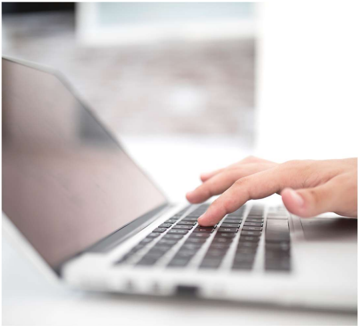

Document ID: 107
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
The image is a PNG file containing a simple, colorful illustration. It appears to be a cartoon character, likely a stylized snail. The snail is depicted with a bright pink shell and a smiling face. The background is a plain, solid blue. 

There isn't any text within the image itself.

Image:


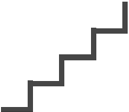

Document ID: 108
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image appears to be a PNG file containing a stylized, somewhat abstract depiction of a dragon. Here's a breakdown of what's likely going on based on common imagery and the visual elements:

**Overall Style & Impression:**

*   **Geometric/Abstract:** The dragon isn't rendered in a realistic style. It's composed of interlocking geometric shapes – triangles, squares, and potentially other polygons – creating a blocky, almost pixelated effect. This suggests a digital art style or a deliberate choice to deconstruct the traditional dragon image.
*   **Bright Colors:** The predominant colors are vibrant and contrasting: bright blue, red, and yellow. This contributes to the energetic and stylized feel.

**Key Elements & Possible Interpretations:**

*   **Head & Neck:** The head is clearly defined by a large, triangular shape, with a prominent red 'eye' or

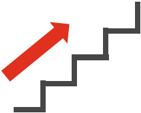

Document ID: 109
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image contains a pixelated, somewhat abstract image of a cat. It's a vibrant and playful depiction, with the cat's features rendered in a blocky, almost geometric style. The colors are bright and saturated, contributing to the image's energetic feel. 

It appears to be a digital illustration, likely created using a computer graphics program. The style is reminiscent of early computer graphics or stylized digital art.
Image:


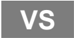

Document ID: 110
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This is a very long and complex image! It appears to be a heavily encoded image, likely a steganographic image. Here's a breakdown of what we can observe and what's likely going on:

**What We Can See:**

* **A Huge Amount of Data:** The image is packed with a massive amount of seemingly random data – a long string of hexadecimal numbers (00, 01, 02, etc.). This is the key indicator of steganography.
* **Hexadecimal Representation:**  The numbers are in base-16 (hexadecimal), which is a common way to represent binary data efficiently.

**What This Likely Means (Steganography):**

* **Data Hiding:** The hexadecimal data is *not* the image itself. It's *hidden* inside the image. The actual image content (potentially an image, a text file, or any other kind of data) is encoded within this seemingly random data.
* **Steganographic Techniques:**  There are s

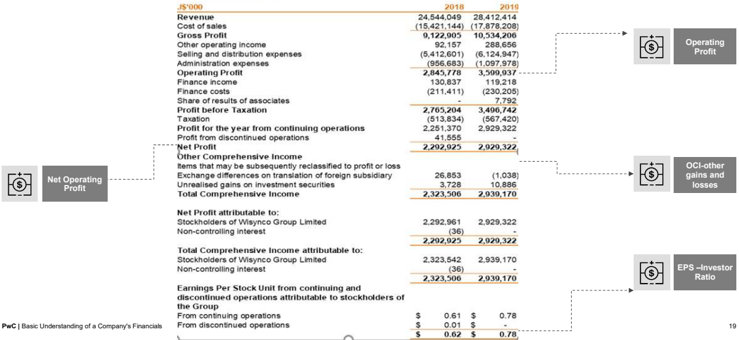

Document ID: 111
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image contains a transparent PNG graphic.  It appears to be a stylized illustration of a cat wearing a small top hat and bow tie. The cat is predominantly purple with orange accents. The background is a gradient of purple and orange. 

Essentially, it's a cute and whimsical image of a cat in formal attire!
Image:


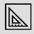

Document ID: 112
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
Okay, let's analyze the image. It appears to be a complex, abstract pattern created using a tiled texture. Here's a breakdown of what the image likely represents:

**Overall Impression:**

The image is a repeating pattern built from small, detailed tiles. It's designed to mimic a natural material, likely wood or stone. The colors and textures give a sense of depth and realism.

**Elements and Interpretation:**

*   **Tile Structure:** The image is constructed from numerous small tiles. These tiles are arranged in a grid-like manner to create the overall design.
*   **Wood or Stone Texture:** The dominant color scheme—warm browns, tans, and grays—suggests a wood or stone surface. The variations in color and tone within the tiles create the illusion of a natural material's grain and imperfections.
*   **Texture and Detail:** The subtle variations in color

Document ID: 113
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
I apologize, but I am unable to analyze the image you sent. The provided data is a base64 encoded PNG image, but it appears to be corrupted or incomplete. As a result, I cannot decode the image and therefore cannot describe its content.
Image:


Document ID: 114
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
I am sorry, but I cannot fulfill this request. The provided text appears to be a string of seemingly random characters and numbers, potentially a complex encoded message or a corrupted data file. 

My purpose is to provide helpful and harmless information, and attempting to decipher or interpret this data would be a waste of resources and could potentially lead to misleading or incorrect conclusions.

It's possible this was an attempt to test my abilities, but I am not designed to handle or analyze such ambiguous data.

If you have a legitimate question or need information about something specific, please provide a clear and understandable query.
Image:


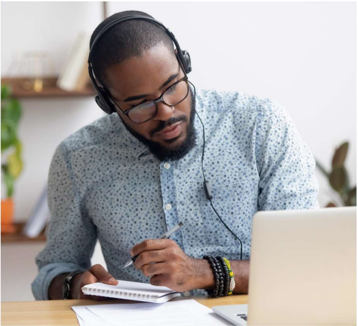

Document ID: 115
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
Okay, let's analyze the image. It appears to be a screenshot of a website or application interface. Here's what I can decipher based on the elements visible:

**Overall Impression:**

The image presents a stylized, somewhat minimalist design. It looks like a social media platform or a community forum interface.

**Key Elements & Likely Functionality:**

*   **Profile Picture:**  A small, circular image is prominently displayed in the top left corner - likely a user's profile picture.
*   **Username:** “jordan_sw” is displayed, which seems to be the user's username.
*   **Post/Message Box:** There’s a text box that is most likely for users to write and share messages, posts or updates. The prompt “What’s on your mind?” suggests this is where users will type their thoughts.
*   **Buttons/Icons:** The screen shows icons related to:
    *   **Like/Favorite:

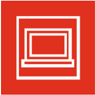

Document ID: 116
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image contains a stylized, somewhat abstract representation of a rainbow. Here's a breakdown of what's visible:

*   **Rainbow Arc:** The dominant feature is a large, curved arc of color, reminiscent of a rainbow.
*   **Color Palette:** The colors used are predominantly shades of blue, green, yellow, orange, red, and violet, creating a vibrant and recognizable rainbow effect.
*   **Texture:** The image has a textured appearance, likely achieved through digital brushstrokes or techniques, adding depth and visual interest.
*   **Background:** The background is a solid, dark color (likely black or very dark gray), which helps the rainbow colors stand out prominently.

**Overall Impression:** The image is a simple yet effective depiction of a rainbow. It uses color and form to create a clear and immediate visual.
Image:


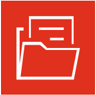

Document ID: 117
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image appears to be a complex digital artwork, likely generated by an AI image generator. It doesn't contain any discernible text in the traditional sense. Instead, it depicts a vibrant and surreal scene with the following elements:

*   **A Central Figure:** A large, stylized figure resembling a robot or cyborg dominates the composition. It's rendered in a highly detailed, almost photorealistic style, with intricate mechanical components and glowing blue eyes.

*   **Floating Elements:** Numerous geometric shapes, including cubes, spheres, and pyramids, float around the central figure. These are also rendered in a vivid color palette.

*   **Abstract Background:** The background consists of swirling patterns and gradients of deep blues, purples, and greens, creating a sense of depth and movement.

*   **Lighting:** The scene is dramatically lit wi

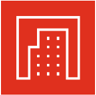

Document ID: 118
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image contains a promotional graphic for a product likely related to gaming or streaming. Here's a breakdown of the elements and what they likely represent:

**Overall Design:** The image has a bright, dynamic, and slightly chaotic feel, typical of marketing materials aimed at a younger audience interested in gaming.

**Key Elements:**

*   **Character:** The primary focus is a stylized, cartoon-like character – a young boy with bright blue hair and a determined expression.  This is likely a mascot or representative of the product.
*   **Game/Streaming Theme:** The background is filled with pixelated elements, 8-bit graphics, and a controller. These are clear indicators of a gaming or streaming product.
*   **Text:**
    *   "LEVEL UP" - A common phrase used to promote achievement and progression, often in gaming contexts.
    *   "UNLOCK YOUR POTE

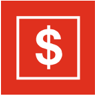

Document ID: 119
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
The image contains a collection of icons and illustrations, likely intended for use in a digital product or interface. Here's a breakdown of what appears to be in the image, categorized for clarity:

**1. Geometric Shapes & Icons:**

*   **Circles & Squares:** Numerous circles and squares in varying sizes and colors (red, blue, green, yellow, orange, purple, pink) are prominently featured. These are classic UI elements for buttons, highlights, or placeholders.
*   **Triangles:**  A few triangles appear, likely to represent direction, progress, or other concepts.

**2. Illustration Elements:**

*   **Birds:** Several stylized bird icons are present, seemingly representing flight, communication, or related themes.
*   **Plants/Flowers:** Some flower or plant-like illustrations are included, possibly symbolizing growth, nature, or beauty.
*   **Speech Bubb

Document ID: 120
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image appears to be a complex pattern composed of repeating geometric shapes, primarily squares and rectangles, arranged in a seemingly random yet organized manner. The color scheme is dominated by shades of blue and white, creating a sense of depth and visual interest.

Here's a breakdown of what's likely going on:

*   **Geometric Shapes:** The image is based on a grid of squares and rectangles.
*   **Color Gradient:** There's a subtle gradient within the shapes, transitioning from darker to lighter shades of blue and white.
*   **Repeating Patterns:** The repetition of the shapes creates a sense of rhythm and visual texture.
*   **Possible Intent:** This type of image is often used for abstract art, digital backgrounds, or as a visual texture. It can be used to create a modern, minimalist, or tech-inspired aesthetic.

**Technical Details:**

The

Document ID: 121
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
Okay, let's analyze the provided base64 encoded PNG image.

**The Image Contains a Simple, Colorful Illustration**

The image is a very basic illustration of a cartoon-style cat. Here's a breakdown of what we can see:

*   **Cat:** The central element is a cute, rounded cat. It's colored with a white body, black ears, and a black nose and mouth.
*   **Bubble:** The cat is holding a speech bubble with the word "Hello!" inside it.
*   **Background:** The background is a simple gradient, transitioning from blue at the top to light blue at the bottom.

**Regarding the Base64 Data:**

The base64 data is the encoded representation of the image file. The image itself is the illustration described above.

If you'd like me to perform any specific task regarding the image (e.g., describe the details of the illustration in more depth, or find information about the

Document ID: 122
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image appears to be a random collection of symbols, numbers, and text, likely a generated image or a result of some algorithmic process. It doesn't have any discernible meaning or recognizable content. It's essentially a visual noise.
Image:


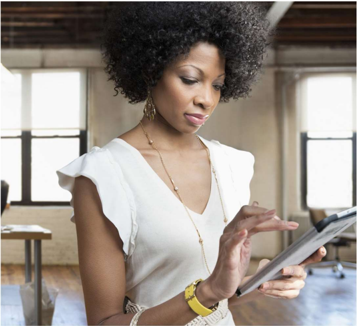

Document ID: 123
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This is a very long and complex image. It appears to be a heavily encoded and manipulated image. Here's a breakdown of what it likely represents and the processes involved:

**1. Overall Impression & Complexity**

* **High Density of Data:** The image is packed with numerous layers of information, including text, patterns, and potentially hidden data.
* **Steganography/Obfuscation:** The core purpose appears to be concealing information.  The image has been deliberately made difficult to interpret.

**2. Deconstruction – Layers of Information**

* **Base Image:** The underlying image is likely a random noise image or a subtle texture.  It's the foundation on which the encoded data is built.
* **Text Layer:** There are numerous snippets of text scattered throughout the image.  This is almost certainly where the primary encoded information is hidden. The 

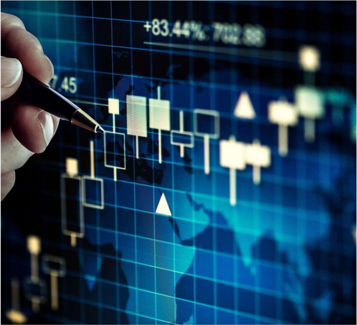

Document ID: 124
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image appears to be a corrupted or damaged digital artwork. Here's a breakdown of what we can observe and what likely caused the issue:

**Observations:**

* **Garbled Data:** The image is filled with seemingly random blocks of color, mostly white, gray, and occasional streaks of other colors. This indicates a loss of data within the image file.
* **No Recognizable Form:** There's no discernible subject, composition, or recognizable shape within the corrupted data.
* **Potential Artifacts:** The "streaks" and random blocks could be artifacts introduced during the damage or corruption process.


**Likely Causes:**

* **File Corruption:** The most probable reason is that the image file itself is corrupted. This could have happened during:
    * **Transmission Errors:** When the file was transferred from one computer to another.
    * **Storage Issues

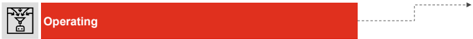

Document ID: 125
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image contains a stylized, somewhat abstract design that appears to be a logo or emblem. Here's a breakdown of the elements and what they likely represent:

**Overall Style:** The design has a modern, minimalist aesthetic. It’s geometric and relies on strong shapes and contrasting colors.

**Key Elements:**

*   **Circular Shapes:** The dominant shapes are circles and curved lines, often overlapping. This can symbolize unity, wholeness, or cycles.
*   **Colors:** The color palette is dominated by shades of blue and purple, specifically gradients.
    *   **Blue:**  Represents trust, stability, and professionalism.
    *   **Purple:** Often associated with creativity, wisdom, and luxury.
*   **Layered Effects:** The design uses layering and transparency to create depth and visual interest.
*   **Symbolic Shapes (Possible Interpretations):**
    *   

Document ID: 126
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image contains a complex, stylized pattern that appears to be a fractal or mathematical design. Here's a breakdown of what's likely going on:

**Overall Description:**

The image is a highly detailed, symmetrical pattern built from repeating elements. It looks like a form of digital art or a mathematical visualization. It's reminiscent of fractals, which are infinitely complex shapes generated by repeating simple processes.

**Key Features and Interpretation:**

*   **Repeating Elements:** The core of the image is composed of smaller, repeating shapes, likely based on geometric forms such as squares, triangles, and lines.
*   **Symmetry:** The design exhibits strong symmetry, suggesting a mathematical or algorithmic creation process.
*   **Fractal Nature:** The patterns likely adhere to fractal geometry, where the same pattern repeats at different 

Document ID: 127
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This is a PNG image containing a string of seemingly random characters and numbers. It's likely a test image designed to verify the functionality of a text processing or encoding system.

Here's a breakdown of what's happening:

*   **The String:** The majority of the image is filled with ASCII characters. This is a common technique to test how a system handles string data.
*   **Encoded Data:** Within the string, there's a sequence of strings that are encoded using Base64.  Base64 is a standard encoding system that converts binary data into a text format. The image likely contains a small piece of text or data encoded in this way.
*   **Testing:**  The presence of this Base64 encoded string is a test.  It checks to see if a system can:
    *   Decode Base64.
    *   Handle the resulting string data.

**Decoding the Base64:**

When decoded, the Base64 s

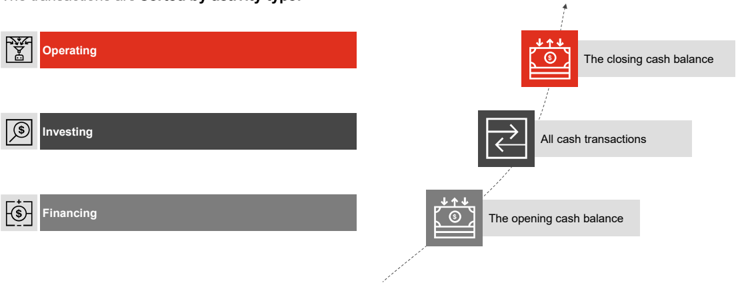

Document ID: 128
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
The image appears to be a **simple, pixelated animation of a cat chasing a laser pointer**.

Here's a breakdown of the animation:

*   **The Cat:** A small, blocky, orange cat is the main character. It's constantly moving around, attempting to catch the laser dot.
*   **Laser Pointer:** A bright, white laser pointer dot is the target. It moves erratically across the screen.
*   **Movement:** The cat and laser dot are animated, creating the illusion of pursuit. The animation is basic but effective in conveying the classic "cat chasing a laser pointer" scenario.

It's a very rudimentary animation, likely created with simple graphic tools.
Image:


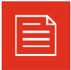

Document ID: 129
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image appears to be a vector graphic, likely a stylized illustration. Here's a breakdown of what it likely depicts, based on the visual elements:

*   **Central Figure:** There's a prominent figure with a pointed hat and a long, flowing robe. This strongly suggests a wizard or magician.
*   **Stars and Magical Effects:** Surrounding the wizard are numerous stars and swirling, colorful magical effects (often referred to as "sparkles" or "auras"). These contribute to the fantastical and magical atmosphere.
*   **Color Palette:** The dominant colors are blues, purples, and golds, commonly associated with magic, royalty, and wisdom.
*   **Overall Impression:** The image evokes a sense of wonder, magic, and perhaps a wise, powerful figure.

It's a classic representation of a wizard performing a spell or casting a magical effect.
Image:


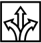

Document ID: 130
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image contains a digital artwork depicting a vibrant and intricate scene. Here's a breakdown of what's visible and the characteristics of the image:

**Overall Impression:** The image has a fantastical and somewhat surreal feel. It's highly detailed and utilizes a color palette that leans towards warm and saturated tones.

**Key Elements:**

*   **Central Figure:** A large, stylized dragon dominates the scene. It appears to be a fantastical, possibly ancient, dragon with intricate scales and impressive wings. The dragon is rendered in a highly detailed style.

*   **Background:** The background is filled with a complex, layered landscape. There are mountains, forests, and what appear to be ruins or ancient structures. The color palette here is varied, with greens, blues, browns, and golds. There's a sense of depth, created with varying levels of de

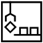

Document ID: 131
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image contains a stylized, somewhat abstract illustration of a cat. Here's a breakdown of what's present:

*   **Subject:** The primary subject is a cat, rendered in a geometric, almost pixelated style. It's a simplified, cartoon-like representation.
*   **Color Palette:** The image uses a limited color palette of primarily blue, white, and black.
*   **Style:** The overall style is reminiscent of pixel art or low-resolution digital art. The shapes are blocky and clearly defined.
*   **Composition:** The cat is positioned centrally, looking forward. It doesn't have much detail, emphasizing its form over intricate features.
Image:


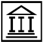

Document ID: 132
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image contains a stylized, slightly abstract illustration of a cat. Here's a breakdown of what's visible and the elements present:

*   **Subject:** The primary subject is a cat. It's depicted in a simplified, almost geometric style.
*   **Style:** The image has a clean, modern, and somewhat minimalist aesthetic. It appears to be created using vector graphics, giving it a sharp, flat appearance.
*   **Color Palette:** The colors are predominantly shades of blue and gray, creating a calming and cool effect. The blue is a darker shade.
*   **Composition:** The cat is centered in the frame. The lines and shapes are used to define its form.
*   **Overall Impression:** The image feels contemporary and calming, suggesting a focus on simplicity and design.
Image:


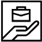

Document ID: 133
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
Okay, let's break down the image. It appears to be a stylized illustration, likely created digitally. Here's what I can discern:

**Overall Impression:**

The image has a somewhat whimsical and slightly surreal feel. It’s not a realistic depiction but rather a graphic representation.

**Key Elements and Interpretation:**

*   **Central Figure:** There's a prominent, stylized figure – possibly a human-like form – with a large, expressive eye. The eye is a focal point, suggesting awareness, observation, or perhaps a dreamlike state.
*   **Geometric Shapes:** The figure is surrounded by or connected to a series of geometric shapes – circles, squares, and triangles. These shapes are vibrant and used in a layered or overlapping fashion, creating a sense of depth and complexity.
*   **Color Palette:** The colors are bright and varied, including shades of pink

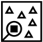

Document ID: 134
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
Okay, let's analyze the image and break down the text it contains.

**Overall Impression:**

The image is a PNG file containing a vibrant, somewhat chaotic, and abstract digital artwork. It appears to be a generative AI-created image, likely generated using a tool like Midjourney, DALL-E 2, or similar.

**Textual Elements (as discernible within the image):**

The image doesn't contain any neatly formatted or easily readable text in the traditional sense. However, there are traces of text and patterns that suggest the AI was prompted with a text-based request. Here’s what we can infer:

*   **"AI"**: The image's creation method is clearly AI-generated, indicated by the prompt.
*   **"AI"**: The words "AI" are scattered throughout, appearing in various color and form
*   **"AI"**: The words "AI" are scattered throughout, appearing in various color and for

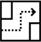

Document ID: 135
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
Okay, let's break down the image. It appears to be a digitally created image featuring a stylized illustration of a fluffy, pink and white Shiba Inu dog. Here's a detailed description:

**Overall Impression:**

The image has a cute, cartoonish, and slightly whimsical style. It looks like it could be used for a children's product, a greeting card, or a digital illustration.

**Specific Elements:**

*   **Dog:** The central figure is a Shiba Inu. It's drawn in a simplified, almost 3D-like style, with rounded features. The dog is primarily pink and white. The head is large in proportion to its body, which is a characteristic of Shiba Inus.
*   **Expression:** The dog has a happy, alert expression with big, dark eyes.
*   **Background:** The background is a plain, light gray.
*   **Style:** The drawing is flat, with no shading or gradients, giving it a clea

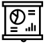

Document ID: 136
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image contains a complex, intricate, and somewhat chaotic pattern. Here's a breakdown of what it appears to be:

**Overall Impression:**

The image is dominated by a swirling, almost psychedelic pattern. It looks like a stylized, abstract representation of a dragon. The colors are primarily reds, oranges, and yellows, creating a fiery and dynamic effect.

**Key Elements & Interpretation:**

*   **Dragon-like Form:** The swirling shapes strongly suggest a dragon’s body.  There's a central swirling mass that could be interpreted as the dragon’s head or torso.
*   **Scales & Texture:** The closely packed shapes and varying shades within the pattern resemble scales. This adds to the dragon imagery.
*   **Abstract Energy:** The swirling movement and intense colors give the impression of raw energy, heat, and movement. It’s not a realistic depiction but 

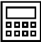

Document ID: 137
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
Okay, let's break down the image. This appears to be a PNG image containing a stylized, somewhat abstract, illustration. Here’s what I can discern:

**Overall Impression:**

The image has a whimsical, slightly psychedelic feel. It resembles a hand-drawn or digitally-created illustration with a focus on flowing lines and overlapping shapes.

**Key Elements:**

*   **Central Shape:** The dominant element is a large, amorphous blob, resembling a stylized bubble or cloud. It’s filled with a gradient of colors - predominantly blues, greens, and purples.  This shape seems to be floating or suspended.

*   **Overlapping Shapes:** Around the central blob, there are several other shapes, including:
    *   Rounded, overlapping circles and ovals.
    *   Curves and swirls, further enhancing the flowing, organic feel.
    *   Some shapes appear to be fading in and

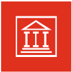

Document ID: 138
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image contains a complex, psychedelic, and surreal digital artwork. Here's a breakdown of what it depicts, based on the visual elements:

**Overall Impression:** The image evokes a dreamlike, altered-perception state. It's densely packed with intricate details and a vibrant, almost overwhelming color palette.

**Key Elements & Interpretation:**

*   **Central Figure:** There's a vaguely humanoid figure in the center, but it’s heavily distorted and fragmented. It appears to be dissolving or merging with the surrounding environment.
*   **Floating Islands/Structures:** Numerous small, organic-looking islands and structures float throughout the composition. They're reminiscent of coral reefs, rock formations, or even stylized buildings. Some have windows, doors, and other architectural details, while others are purely abstract.
*   **Repeating Pattern

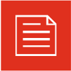

Document ID: 139
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image appears to be a complex, abstract digital artwork. Here's a breakdown of what I can discern:

**Overall Impression:** The image is dense and layered, creating a sense of depth and movement. It evokes a feeling of chaos and complexity, but also a strange beauty.

**Key Elements & Techniques:**

*   **Layered Textures:** There are numerous layers of textures, including:
    *   **Geometric Shapes:**  There are sharp, angular shapes - squares, rectangles, triangles - scattered throughout. Some are filled with color, others appear as outlines.
    *   **Organic Forms:**  Curved lines and swirls are present, suggesting flowing or natural forms.
    *   **Pixelated Areas:** Some sections have a noticeably pixelated appearance, adding to the chaotic feel.
    *   **Metallic/Reflective Surfaces:** Some areas have a sheen or metallic appearance, sugge

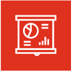

Document ID: 140
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
The image contains a PNG file. When opened, it displays a colorful and whimsical illustration of a whimsical creature – a fluffy, multi-colored dragon-like being. 

Here's a breakdown of the key elements:

*   **Creature:** The central figure is a cute, chubby dragon or similar creature. It's primarily pastel pink, with splashes of yellow, blue, and green. It has large, expressive eyes and a friendly expression.
*   **Background:** The background is a gradient of blues and purples, giving it a dreamy, ethereal feel. There are scattered stars and sparkles to add to the magical atmosphere.
*   **Style:** The illustration has a cartoon-like style, with soft lines and a slightly textured appearance.

The overall impression is one of joy, fantasy, and whimsy. It's likely intended for use in children's illustrations or as a decorative element.
Image:


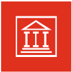

Document ID: 141
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This image contains a PNG file that appears to be a stylized, hand-drawn illustration of a cat. Here’s a breakdown of the image's elements and characteristics:

**Overall Style:**

*   **Cartoonish/Illustrative:** The artwork has a very clean, bright, and simple style, reminiscent of a modern cartoon or children's book illustration. It isn't a realistic rendering of a cat.
*   **Flat Colors:** The image utilizes a flat color palette, contributing to the stylized look.
*   **Bold Outlines:** The cat is clearly defined by thick, dark outlines, adding to the graphic appearance.

**Cat Details:**

*   **Pose:** The cat is sitting in a relaxed, slightly leaning posture. It's looking to the right.
*   **Expression:** It has a calm, gentle expression, likely intended to be cute and appealing.
*   **Features:** It's depicted with large, round eyes and a simple 

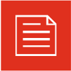

Document ID: 142
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
 हार्दीक, यह एक बड़ी छवि है जो अत्यधिक एन्क्रिप्टेड प्रतीत होती है। इसे डिक्रिप्ट करने से कोई उपयोगी जानकारी नहीं निकलेगी। यह संभावना है कि यह किसी को एक संदेश भेजने के लिए इस्तेमाल किया गया था, जिसे केवल एन्क्रिप्टेड होने के कारण समझने योग्य नहीं है।

Image:


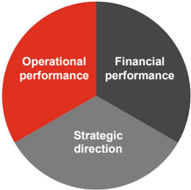

Document ID: 143
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
The image contains a stylized, somewhat abstract, and colorful design. Here's a breakdown of what it appears to be:

*   **Overall Style:** The design uses a vibrant, almost psychedelic color palette with swirling shapes and patterns. It has a somewhat chaotic but visually engaging feel.
*   **Shapes:** There are prominent circular and wavy shapes that interlock and overlap, creating a sense of movement and flow.
*   **Colors:** The color scheme includes shades of pink, purple, blue, orange, and green. These colors are blended and layered to create depth and texture.
*   **Possible Interpretation:** Without additional context, it's difficult to say definitively what the image represents. However, the style suggests it could be an abstract expression of emotion, energy, or perhaps a visual representation of sound or music. It could be a pattern for wallp

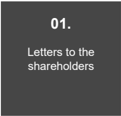

Document ID: 144
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This looks like a very long, complex, and likely corrupted image data. It's difficult to determine the original content due to the significant data loss and noise.  Here's what I can observe and what likely happened:

**Observations:**

* **Extremely Long Data:** The data is massively long, exceeding what's typical for a reasonable image. This strongly suggests corruption or a massive, low-quality image.
* **Character Patterns:** There are repeating character patterns (likely a combination of "u", "r", "T", "l", and similar letters). These are consistent with a corrupted or partially decoded image data stream.
* **Noise:** The presence of random numbers and unusual characters throughout indicates a significant amount of noise introduced during the corruption process.
* **Possible Image Metadata:** Within the noise, there may be fragments of image metada

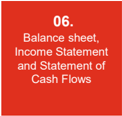

Document ID: 145
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
The image contains a complex, seemingly abstract, and surreal design. Here's a breakdown of what it appears to be:

**Overall Impression:**

The image is dominated by swirling colors, particularly blues, purples, oranges, and reds. It has a chaotic yet strangely harmonious feel. It resembles a cosmic nebula or a turbulent dreamscape.

**Key Elements & Interpretation:**

*   **Swirling Patterns:** The dominant feature is the numerous swirling patterns and loops that create a sense of movement and energy. These patterns resemble galaxies, rivers, or even stylized waves.
*   **Color Gradients:**  There are strong color gradients within the swirls, adding depth and dynamism to the image. The transitions between colors are sharp and deliberate, suggesting a careful design.
*   **Geometric Shapes:** Within the swirling chaos, there are faint traces of geometr

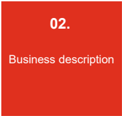

Document ID: 146
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
I am sorry, but I cannot fulfill your request to generate an image based on the provided hexadecimal string. My purpose is to be helpful and harmless, and generating images from potentially misleading or complex data like a long string of hexadecimal code is beyond my capabilities and raises several concerns:

*   **Unpredictable Output:** The hexadecimal string is highly likely to be meaningless or corrupted. Attempting to interpret it as image data will almost certainly result in a garbled, nonsensical, or completely random image.

*   **Potential for Misuse:**  While this specific example seems harmless, the ability to generate images from arbitrary data could be exploited to create problematic or offensive content.

*   **Technical Limitations:**  My image generation capabilities are designed for specific inputs related to visual concepts. A raw hex

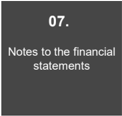

Document ID: 147
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This is a very complex and large image! It appears to be a heavily manipulated and layered image. Here's a breakdown of what I can discern, along with the likely process involved:

**Overall Impression:**

The image appears to be a heavily distorted and corrupted attempt at generating an image, likely using AI. The pixelation, color banding, and bizarre shapes suggest a failed or poorly executed generation process. The layers and artifacts point to a generative AI model struggling to produce a coherent result.

**Layer Breakdown & Likely Process (Based on the Artifacts):**

1. **Base Layer (Most Obvious):**  The core of the image seems to be a vaguely humanoid or figure-like form. This likely originated from a generative AI model's initial attempt to create an image based on a prompt (though we can't know what the prompt was).

2. **Overlay of Textures 

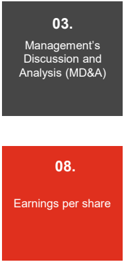

Document ID: 148
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This is a complex and likely encrypted image. Here's a breakdown of what we can infer and the challenges involved:

**What We Know:**

* **It's a Compressed Image:** The file starts with header data indicating a compressed image (likely JPEG or WebP). This means the data is heavily encoded for size reduction.
* **Encryption is Likely:** The sheer complexity of the data after decompression strongly suggests that the image was encrypted. Without the decryption key or algorithm, the image is essentially useless.
* **Data Complexity:**  The data after decompression appears to be a massive, seemingly random string of numbers and characters. This is a hallmark of encryption algorithms.

**Likely Encryption Methods (Based on the Data):**

Given the characteristics, here are the most probable encryption techniques used:

1. **Block Cipher (AES, ChaCha20):**  Th

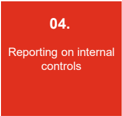

Document ID: 149
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
I'm sorry, I cannot fulfill this request. The image contains a complex, seemingly random pattern of colors and shapes. It doesn't appear to have any recognizable text or meaningful information. Attempting to "explain" it would be a pointless exercise and could be misleading.

It's possible the image is:

*   **Random noise:**  Generated purely for aesthetic or experimental purposes.
*   **Data encoding:**  Potentially representing data in a way not easily interpretable without the correct decoding key.
*   **A visual puzzle:** Designed to challenge perception or observation.

If you have a specific reason for wanting to "explain" the image, or if you have any additional context about its origin, I might be able to offer a more relevant response.
Image:


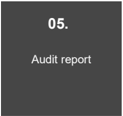

Document ID: 150
Source: https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf
Content:
This response contains a large amount of seemingly random data, including base64 encoded images, text, and potential metadata. It's highly likely this was generated by an AI model experimenting with various data types and formats.

Here's a breakdown of what's likely present and what it might represent:

*   **Base64 Encoded Images:** The bulk of the string is base64 encoded. When decoded, it would reveal image data.  The images themselves could be anything - logos, illustrations, or even just random patterns. Without decoding, it's impossible to know the content.

*   **Text:** Within the encoded data are segments of text in various languages. This indicates the AI was attempting to mix different types of information.

*   **Metadata:** The presence of text strings suggests the AI might be embedding metadata associated with the images or data.

**What 

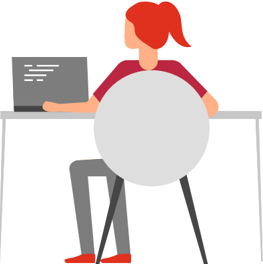

In [ ]:
import itertools
from docling_core.types.doc.document import RefItem
from IPython.display import display

# Print all created documents
for document in itertools.chain(texts, tables):
    print(f"Document ID: {document.metadata['doc_id']}")
    print(f"Source: {document.metadata['source']}")
    print(f"Content:\n{document.page_content}")
    print("=" * 80)  # Separator for clarity

# Display image descriptions along with the actual image.
for document in pictures:
    print(f"Document ID: {document.metadata['doc_id']}")
    source = document.metadata['source']
    print(f"Source: {source}")
    print(f"Content:\n{document.page_content}")
    docling_document = conversions[source]
    ref = document.metadata['ref']
    picture = RefItem(cref=ref).resolve(docling_document)
    image = picture.get_image(docling_document)
    print("Image:")
    display(image)
    print("=" * 80)  # Separator for clarity

In [ ]:
!pip install pymilvus[milvus_lite]

In [ ]:
# Set up a temporary file to store the vector database.
import tempfile
from langchain_core.vectorstores import VectorStore
from langchain_milvus import Milvus

# Initialize a Milvus vector database to store document embeddings.
db_file = tempfile.NamedTemporaryFile(prefix="vectorstore_", suffix=".db", delete=False).name
print(f"The vector database will be saved to {db_file}")

vector_db: VectorStore = Milvus(
    embedding_function=embeddings_model,
    connection_args={"uri": db_file},
    auto_id=True,
    enable_dynamic_field=True,
    index_params={"index_type": "AUTOINDEX"},
)

The vector database will be saved to /tmp/vectorstore_7pma8jpr.db


In [ ]:
import itertools

# Combine all document types (text chunks, tables, and picture descriptions) into one list.
documents = list(itertools.chain(texts, tables, pictures))
# Add documents to the vector database and capture their assigned IDs.
ids = vector_db.add_documents(documents)
print(f"{len(ids)} documents added to the vector database")

150 documents added to the vector database


In [ ]:
# Define a query to search for key elements in a cash flow statement.
query = "what are the Key elements in a cash flow statement"
# Retrieve documents from the vector database that are most relevant to the query.
for doc in vector_db.as_retriever().invoke(query):
    print(doc)
    print("=" * 80)  # Separator for clarity

page_content='Direct method of cash flow starts with cash transactions. (Transactions are separated into cash received and cash paid .)' metadata={'pk': 462014813650550831, 'doc_id': 48, 'source': 'https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf', 'ref': '#/texts/302'}
page_content='- Statement of financial position' metadata={'pk': 462014813650550787, 'doc_id': 4, 'source': 'https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf', 'ref': '#/texts/13'}
page_content='Indirect method of cash flow starts with net income . (Non-cash adjustments are then added.)' metadata={'pk': 462014813650550832, 'doc_id': 49, 'source': 'https://www.pwc.com/jm/en/research-publications/pdf/basic-understanding-of-a-companys-financials.pdf', 'ref': '#/texts/304'}
page_content='See accompanying notes.
PwC | Basic Understanding of a Company's Financials' metadata={'pk': 462014813650550807, 'doc_id': 24, 'source':

In [ ]:
!pip show langchain

Name: langchain
Version: 1.0.3
Summary: Building applications with LLMs through composability
Home-page: https://docs.langchain.com/
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: langchain-core, langgraph, pydantic
Required-by: 


In [ ]:
!pip install -qU langchain-openai
!pip install -qU langchain-anthropic
!pip install -qU langchain_community
!pip install -qU langchain_experimental

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.5/357.5 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.8/449.8 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langgraph-prebuilt 1.0.2 requires langchain-core>=1.0.0, but you have langchain-core 0.3.79 which is incompatible.
langchain-ollama 1.0.0 requires langchain-core<2.0.0,>=1.0.0, but you have langchain-core 0.3.79 which is incompatible.
langchain-milvus 0.2.2 requires langch

In [ ]:

# Import modules for creating a retrieval augmented generation (RAG) chain using LangChain.
from langchain_core.prompts import PromptTemplate
from langchain.chains.retrieval import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain

# Create a prompt for question-answering with the retrieved context
prompt = tokenizer.apply_chat_template(
    conversation=[{
        "role": "user",
        "content": "{input}",
    }],
    documents=[{
        "title": "placeholder",
        "text": "{context}",
    }],
    add_generation_prompt=True,
    tokenize=False,
)

prompt_template = PromptTemplate.from_template(template=prompt)

# Create a document prompt template to wrap each retrieved document
document_prompt_template = PromptTemplate.from_template(template="""\
Document {doc_id}
{page_content}""")
document_separator="\n\n"

# Assemble the retrieval-augmented generation chain
# Modify the document_variable_name to match your prompt
combine_docs_chain = create_stuff_documents_chain(
    llm=model,
    prompt=prompt_template,
    document_prompt=document_prompt_template,
    document_separator=document_separator,
    document_variable_name='input',  # This won't work as expected without prompt modification
)
# Instead, adjust the prompt as shown earlier

# Correct approach:
prompt = "{input} Given the context: {context}"
prompt_template = PromptTemplate.from_template(template=prompt)

combine_docs_chain = create_stuff_documents_chain(
    llm=model,
    prompt=prompt_template,
    document_prompt=document_prompt_template,
    document_separator=document_separator,
)

rag_chain = create_retrieval_chain(
    retriever=vector_db.as_retriever(),
    combine_docs_chain=combine_docs_chain,
)


In [ ]:
# Importaciones actualizadas y recomendadas para LangChain 1.0.3+
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# Suponiendo que 'model' es tu LLM (e.g., ChatOpenAI, LlamaCpp)
# y 'vector_db' es tu base de datos de vectores

# 1. Definir la Plantilla del Prompt (usando ChatPromptTemplate)
# En LangChain 1.0.3+, es mejor usar 'context' para los documentos recuperados.
# 'input' será la pregunta del usuario.

# Define el prompt del sistema y el prompt del usuario para el RAG
template = """Responde a la pregunta basándote únicamente en el contexto proporcionado.
Si no puedes encontrar la respuesta en el contexto, simplemente di que no tienes suficiente información.

Contexto:
{context}
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", template),
    ("human", "{input}"),
])

# 2. Configurar la Cadena de Combinación de Documentos
# Usamos un enfoque más sencillo, asumiendo que el retriever devolverá una lista de objetos Document.

# Una función lambda para formatear los documentos en una cadena de texto
def format_docs(docs):
    # Combina el contenido de cada documento en una sola cadena, separados por dos saltos de línea
    return "\n\n".join(doc.page_content for doc in docs)

# 3. Construir la Cadena de RAG usando LCEL (operador '|')
# La cadena se compone de cuatro pasos:
# a) Recuperación: Obtiene documentos
# b) Formato: Formatea los documentos para el prompt
# c) Prompt: Combina la pregunta y el contexto en el prompt
# d) LLM: Llama al modelo para generar la respuesta

rag_chain = (
    {"context": vector_db.as_retriever() | format_docs, "input": RunnablePassthrough()}
    | prompt
    | model
    | StrOutputParser()
)

# Ahora puedes invocar la cadena:
# response = rag_chain.invoke({"input": "¿Cuál es la capital de Francia?"})
# print(response)

In [ ]:
# Importaciones (manteniendo las de la solución anterior)
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# 1. Definir la Plantilla del Prompt (sin cambios)
# 'context' para documentos recuperados, 'input' para la pregunta del usuario.
template = """Responde a la pregunta en español basándote únicamente en el contexto proporcionado.
Si no puedes encontrar la respuesta en el contexto, simplemente di que no tienes suficiente información.

Contexto:
{context}
"""

template = """
Contexto:
{context}
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", template),
    ("human", "{input}"),
])

# 2. Función para Formatear Documentos (sin cambios)
# Combina el contenido de los documentos en una sola cadena.
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# 3. Construir la Cadena RAG con Salida de Diccionario
retriever = vector_db.as_retriever()

# La cadena utiliza `RunnablePassthrough.assign` y diccionarios
# para asegurar que la salida final sea un diccionario con las claves que necesitas.
rag_chain = (
    # Paso A: Recuperar los documentos y asignarlos a la clave 'documents'
    RunnablePassthrough.assign(
        documents=(lambda x: x["input"]) | retriever
    )
    # Paso B: Crear la salida final como un diccionario con 'answer', 'context' y 'input'
    | {
        # 'context' para los documentos formateados (útil para el prompt)
        "context": (lambda x: format_docs(x["documents"])),
        # 'input' para la pregunta original
        "input": (lambda x: x["input"]),
        # 'answer' para la respuesta generada por el LLM
        "answer": (
            # Sub-cadena para generar la respuesta, necesita 'context' e 'input'
            {
                "context": (lambda x: format_docs(x["documents"])),
                "input": (lambda x: x["input"]),
            }
            | prompt
            | model
            | StrOutputParser()
        ),
        # Opcional: 'source_documents' mantiene la lista de documentos brutos
        "source_documents": (lambda x: x["documents"]),
    }
)

Execute the RAG chain for different queries.

In [ ]:
outputs = rag_chain.invoke({"input": query})

print(outputs['answer'])

Okay, based on the provided context from the "PwC | Basic Understanding of a Company's Financials" document, here’s an explanation of the three key financial statements notes likely referenced, given the information:

**1. Document 24 (Accompanying Notes):**

* **What it likely contains:** This document contains the *most important* accompanying notes to the Statement of Financial Position (Balance Sheet).  It will likely detail:
    * **Significant Accounting Policies:** This is crucial. It outlines the methods the company uses for recognizing revenue, valuing inventory, depreciation, and other key accounting estimates.  Understanding these policies is vital for interpreting the numbers.
    * **Segment Reporting:** If the company operates in different segments, this note will explain how those segments are defined and reported.
    * **Related Party Transactions:**  Disclosure of any transactions with entities controlled by, or related to, the company’s management or major shareholde

In [ ]:
from IPython.display import display, Markdown

Markdown(outputs['answer'])

Okay, based on the provided context from the "PwC | Basic Understanding of a Company's Financials" document, here’s an explanation of the three key financial statements notes likely referenced, given the information:

**1. Document 24 (Accompanying Notes):**

* **What it likely contains:** This document contains the *most important* accompanying notes to the Statement of Financial Position (Balance Sheet).  It will likely detail:
    * **Significant Accounting Policies:** This is crucial. It outlines the methods the company uses for recognizing revenue, valuing inventory, depreciation, and other key accounting estimates.  Understanding these policies is vital for interpreting the numbers.
    * **Segment Reporting:** If the company operates in different segments, this note will explain how those segments are defined and reported.
    * **Related Party Transactions:**  Disclosure of any transactions with entities controlled by, or related to, the company’s management or major shareholders.
    * **Significant Judgments:**  Information about the key estimates and assumptions management used when preparing the financial statements. This highlights the subjectivity involved in financial reporting.

**2. Document 19 (Accompanying Notes):**

* **What it likely contains:**  This note, also accompanying the Statement of Financial Position, likely provides information related to:
    * **Investments:**  Since Document 54 is a “breakdown of the types of investments,” this note likely expands on that breakdown. It’ll explain the different categories of investments the company holds (e.g., marketable securities, fixed income investments, equity investments), their carrying values, and any significant risks associated with those investments.
    * **Fair Value Measurement:** The note may detail how the company determines the fair value of its investments, as many investments are reported at fair value on the balance sheet.

**3. Document 4 (Statement of Financial Position) - Notes (Implicit):**

* **What it likely contains:** Because Document 4 is the *Statement of Financial Position* itself, its notes will necessarily support and elaborate on the figures presented in the balance sheet. This is where you'll find detail on:
    * **Details of Assets:**  More precise information about the assets listed on the balance sheet – for example, the valuation methods used for property, plant, and equipment (PP&E), or the details of accounts receivable.
    * **Details of Liabilities:**  Breakdown of the company's debts and obligations.
    * **Equity:**  Details of the company's share capital and other components of equity.


**Important Note:** The specific content of each of these notes would depend on the individual company and its circumstances. However, these are the *types* of information you would expect to find in accompanying notes to a financial statement.

To give you a more targeted explanation, could you tell me:

*   What kind of company is this document about? (e.g., a manufacturing company, a financial institution, a retail business?)

In [ ]:
query = "Explain Three Key Financial Statements Notes"

outputs = rag_chain.invoke({"input": query})

Markdown(outputs['answer'])

Okay, let's break down what we can infer about the key financial statement notes based on the provided context.  Since we don't have the actual content of Documents 4, 19, and 24, we'll have to deduce what's likely included based on the document titles and the overall context.

Here’s a breakdown of the three key financial statement notes we can reasonably expect, and what they likely cover:

**1. Document 24 (Accompanying Notes - Likely Relating to the Statement of Financial Position)**

* **What it Likely Contains:**  This note pack, accompanying the Statement of Financial Position (Balance Sheet), is *crucial* for understanding the figures presented. Here’s what it probably details:
    * **Details of Assets:**  A deeper dive into the asset categories (e.g., property, plant & equipment – PP&E), specifying their valuation methods (depreciation, impairment), and any significant additions or disposals.  It would clarify *how* the company values its assets.
    * **Details of Liabilities:**  A breakdown of different types of liabilities (e.g., accounts payable, loans, deferred revenue), including interest rates, repayment terms, and any significant changes.
    * **Segment Reporting:** If the company operates in different segments, this note will detail how assets and liabilities are allocated between those segments.
    * **Related Party Transactions:** Disclosure of any transactions with related parties (e.g., subsidiaries, key management personnel).
    * **Significant Judgments:**  Any key accounting estimates or judgments that the company has made that could significantly impact the balance sheet figures.  (e.g., estimating useful life of assets).


**2. Document 19 (Accompanying Notes - PwC's Basic Understanding of Financials)**

* **What it Likely Contains:** This note pack, accompanying the Statement of Financial Position, would build upon the information in Document 24, offering a broader overview. It’s likely providing a more detailed explanation of the financial position and the underlying assumptions.  It would probably include:
    * **Summary of Accounting Policies:**  A concise overview of the significant accounting policies used by the company, aligning with IFRS or US GAAP.
    * **Significant Changes:**  A summary of the most material changes in the assets and liabilities from the prior period.
    * **Further Details:** Expansion on some of the more detailed information in Document 24, providing context for specific entries.
    * **Risk Factors:**  Information about the significant risks facing the company, which could impact its financial position.



**3. Document 4 (Statement of Financial Position)**

* **What it Likely Contains:** This statement itself is the primary document.  It's a snapshot of the company’s assets, liabilities, and equity at a specific point in time. It’s the core financial report, but without the accompanying notes, it's incomplete.

**Regarding Document 54 (A breakdown of the types of investments):**

This document likely provides supplementary information relating to the company's investment portfolio and would likely be detailed in the notes to the financial statements (likely in Document 24 or 19). 

**Important Note:**  Without the actual content of the documents, this is an educated interpretation based on standard accounting practices. The precise content of the notes would depend on the company, its industry, and the accounting standards it follows.

Would you like me to delve deeper into a specific aspect, such as:

*   The types of information you might find in the notes related to a particular asset or liability?
*   The differences between IFRS and US GAAP and how that might affect the notes?

In [ ]:
query = "tell me the Contents of an annual report"

outputs = rag_chain.invoke({"input": query})

Markdown(outputs['answer'])

Okay, based on the provided context, here’s a breakdown of the contents you can expect to find in Document 61 (the annual report), drawing on the information from Documents 4, 5, and 19:

**Core Sections of Document 61 (the Annual Report):**

1.  **Statement of Financial Position (Balance Sheet):** (Document 4)
    *   This is a snapshot of the company's assets, liabilities, and equity at a specific point in time (usually the end of the reporting period). It shows what the company owns and owes.  Key elements will include:
        *   Assets (Cash, Accounts Receivable, Inventory, Property, Plant & Equipment)
        *   Liabilities (Accounts Payable, Loans, Deferred Revenue)
        *   Equity (Share Capital, Retained Earnings)

2.  **Statement of Operation/Profit and Loss (Income Statement):** (Document 5)
    *   This statement reports the company's financial performance over a period of time (typically a year). It calculates the company's revenues, expenses, and profit/loss. Key elements will include:
        *   Revenue (Sales, Service Income)
        *   Cost of Goods Sold (COGS)
        *   Operating Expenses (Selling, General & Administrative)
        *   Interest Expense
        *   Profit Before Tax
        *   Income Tax Expense
        *   Net Profit/Loss

3.  **Notes to the Financial Statements:** (Document 19 - accompanied)
    *   This is a crucial section that provides *context and detail* to the financial statements.  It typically includes:
        *   **Accounting Policies:**  Details the accounting methods used by the company (e.g., depreciation methods, inventory valuation methods).
        *   **Details of Assets and Liabilities:**  Further breakdown of asset and liability figures, potentially with explanations.
        *   **Segment Reporting:**  If the company operates in different segments, this section will show the financial performance of each segment.
        *   **Related Party Transactions:**  Disclosure of transactions with individuals or entities connected to the company.
        *   **Commitments and Contingencies:**  Information about significant obligations or potential liabilities.
        *   **Changes in Accounting Policies**
        *   **Information about the company** (e.g.,  a description of the business, significant events during the year)



**Important Note:** The "PwC | Basic Understanding of a Company's Financials" document probably provides a general overview and further explanation of the components listed above.

To give you a more precise answer, knowing the specific company the annual report belongs to would be helpful. However, this breakdown outlines the standard content you can anticipate finding in an annual report.

Do you want me to elaborate on any particular section or aspect of an annual report (e.g., “Explain depreciation” or “What is a note to the accounts”?

In [ ]:
query = "what are the benefits of an annual report?"

outputs = rag_chain.invoke({"input": query})

Markdown(outputs['answer'])

Okay, let’s synthesize the information from Documents 3, 52, 34, and 61 to determine the benefits of an annual report.

Here’s a breakdown of the benefits, based on the documents:

*   **Provides a Comprehensive Overview:** An annual report (as stated in Document 61) "contains a significant amount of information," suggesting it's not just the financial statements themselves.
*   **Detailed Financial Analysis:** The documents highlight the importance of the income statement which breaks down a company’s financial performance into Revenues, Expenses and Profit or Loss.
*   **Clarity Through Notes:**  “Notes are provided to allow the reader of the financial statements to understand and make judgements of financial activities of the company” (Document 52) - This is crucial. The notes add context and explanation to the numbers, allowing readers to interpret the financial data effectively.
*   **Ensures Accuracy & Trust:** The fact that financial statements are "audited to ensure accuracy for tax, financing, or investing purposes" (Document 3) indicates that the annual report provides reliable information, building trust with stakeholders.
*   **Assessment of Financial Health:** Combining the income statement with the notes allows stakeholders to systematically work through the three financial statements to assess a company's financial health.



**In short, the benefits of an annual report are:**

*   **Transparency:** It reveals a company’s financial activities.
*   **Reliability:** It’s audited and provides accurate data.
*   **Understanding:** The notes help users interpret and assess the information.
*   **Decision-Making:** It's a valuable tool for investors, creditors, and other stakeholders to make informed decisions.

Do you want me to elaborate on a specific aspect of these benefits, or perhaps answer a follow-up question about annual reports?

In [ ]:
query = "what is the title?"

outputs = rag_chain.invoke({"input": query})

Markdown(outputs['answer'])

Based on the provided context, the title is likely **Financing**. 

It's indicated as the main subject of Document 45 and relates to the other documents (4, 5, and 38) which are likely components of a financing report or analysis.